# Meteorological Feature Overlap Analysis

**Comprehensive Analysis of MCS, AR, and ETC Interactions**

This notebook implements a scientifically robust framework for analyzing overlaps between:
- **MCS (Mesoscale Convective Systems)**: Smallest scale features
- **AR (Atmospheric Rivers)**: Medium scale features  
- **ETC (Extratropical Cyclones)**: Largest scale features

## Key Features:
- **Meteorologically-informed thresholds** respecting atmospheric scale hierarchy
- **Pair-based filtering** ensuring visual consistency
- **Vectorized overlap detection** for efficiency
- **Comprehensive visualization** of 2-way and 3-way interactions

## Threshold Design:
- **2-way overlaps**: MCS=20%, AR=10%, ETC=5%
- **3-way overlaps**: MCS=20%, AR=10%, ETC=0% (environmental context)

In [1]:
# IMPORTS AND SETUP
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
import cartopy.crs as ccrs
import cartopy.feature as cf
import easygems.healpix as egh
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set figure parameters
plt.rcParams['figure.dpi'] = 144
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [2]:
# LOAD DATA
# Update these paths as needed for your data location
# in_dir = '/global/cfs/cdirs/m1867/zfeng/PyFLEXTRKR/quicklook_dev/sample_data'
# root_dir = '/global/homes/f/feng045/program/hackathon/hk25-teams/hk25-Tracking'
# figdir = f'{root_dir}/figures'

source_name = "scream"
root_dir = "/pscratch/sd/w/wcmca1/hackathon/allmasks/"
in_dir = f"{root_dir}/{source_name}_allmasks_hp8_v1.zarr"

figdir = "/global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_test/"
# figdir = "/pscratch/sd/w/wcmca1/hackathon/"
os.makedirs(figdir, exist_ok=True)

# Load the processed dataset
print(f"Loading data from: {in_dir}")

ds = xr.open_dataset(in_dir)
ds = ds.pipe(egh.attach_coords)
ds

Loading data from: /pscratch/sd/w/wcmca1/hackathon/allmasks//scream_allmasks_hp8_v1.zarr


<xarray.Dataset> Size: 49GB
Dimensions:   (time: 3138, cell: 786432)
Coordinates:
  * time      (time) datetime64[ns] 25kB 2019-08-01T03:00:00 ... 2020-09-01
    crs       int64 8B 0
  * cell      (cell) int64 6MB 0 1 2 3 4 ... 786427 786428 786429 786430 786431
    lat       (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.1492
    lon       (cell) float64 6MB 45.0 45.18 44.82 45.0 ... 315.2 314.8 315.0
Data variables:
    ar_mask   (time, cell) int32 10GB ...
    etc_mask  (time, cell) int32 10GB ...
    mcs_mask  (time, cell) float64 20GB ...
    tc_mask   (time, cell) int32 10GB ...
Attributes: (12/37)
    Contact:                      Zhe Feng: zhe.feng@pnnl.gov
    Conventions:                  CF-1.8
    Created_on:                   Mon May  5 10:42:36 2025
    Institution:                  Pacific Northwest National Laboratory
    NCO:                          netCDF Operators version 5.3.2 (Homepage = ...
    Title:                        HEALPix remapped tracking mask data (zoom=8)
    ...                           ...
    tb_threshold_core:            225.0
    tb_threshold_environment:     261.0
    tb_threshold_warmanvil:       261.0
    topography_file:              /lustre/orion/cli115/world-shared/e3sm/inpu...
    username:                     noel
    zoom:                         8

In [3]:
tm = '2019-11-24T03'
# Select single time step first
_ds = ds.sel(time=tm, method='nearest')

print(f"Dataset loaded successfully!")
print(f"Data variables: {list(_ds.data_vars)}")
print(f"Spatial dimensions: {_ds.dims}")

# Display basic statistics
n_mcs = len(np.unique(_ds.mcs_mask.values[_ds.mcs_mask.values > 0]))
n_ar = len(np.unique(_ds.ar_mask.values[_ds.ar_mask.values > 0]))
n_etc = len(np.unique(_ds.etc_mask.values[_ds.etc_mask.values > 0]))

print(f"\nFeature counts:")
print(f"  MCS tracks: {n_mcs}")
print(f"  AR tracks: {n_ar}")
print(f"  ETC tracks: {n_etc}")

Dataset loaded successfully!
Data variables: ['ar_mask', 'etc_mask', 'mcs_mask', 'tc_mask']
Spatial dimensions: FrozenMappingWarningOnValuesAccess({'cell': 786432})

Feature counts:
  MCS tracks: 108
  AR tracks: 9
  ETC tracks: 9


## Visualize all masks

In [4]:
def plot_all_feature_masks(ds, title="", figsize=(12, 6), colors=None, figname=None, dpi=200, 
                          alphas=None, title_fontsize=14, legend_fontsize=12):
    """
    Plot all 4 feature masks at a single time step.
    
    Parameters:
    - ds: xarray Dataset containing the mask variables (assumes single time step)
    - title: optional title for the plot
    - figsize: figure size tuple
    - colors: dict with color names for each feature type, e.g. {'mcs': 'lightskyblue', 'ar': 'orange', 'etc': 'lightgreen', 'tc': 'lightcoral'}
    - figname: if provided, save figure as PNG with this filename
    - dpi: DPI for figure display and saving (default 200)
    - alphas: dict with alpha values for each feature type, e.g. {'mcs': 0.6, 'ar': 0.7, 'etc': 0.5, 'tc': 0.8}
    - title_fontsize: font size for the plot title (default 14)
    - legend_fontsize: font size for the legend (default 12)
    
    Returns:
    - fig, ax: matplotlib figure and axes objects
    """
    # Set default colors
    if colors is None:
        colors = {
            'mcs': 'lightskyblue',
            'ar': 'orange', 
            'etc': 'lightgreen',
            'tc': 'lightcoral'
        }
    
    # Set default alphas
    if alphas is None:
        alphas = {
            'mcs': 0.6,
            'ar': 0.6,
            'etc': 0.6,
            'tc': 0.6
        }
    
    # Create base map (integrated from worldmap_base)
    projection = ccrs.Robinson(central_longitude=-135)
    fig, ax = plt.subplots(
        figsize=figsize,
        subplot_kw={"projection": projection},
        constrained_layout=True
    )
    fig.dpi = dpi
    ax.set_global()
    ax.add_feature(cf.COASTLINE, linewidth=0.8)
    ax.add_feature(cf.BORDERS, linewidth=0.4)

    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 10}
    gl.ylabel_style = {"size": 10}

    # Set title
    plot_title = title if title else "Feature Masks"
    ax.set_title(plot_title, fontsize=title_fontsize)
    
    # Extract masks (assuming single time step)
    mcs_mask = ds['mcs_mask'].squeeze()
    ar_mask = ds['ar_mask'].squeeze()
    etc_mask = ds['etc_mask'].squeeze()
    tc_mask = ds['tc_mask'].squeeze()
    
    # Convert masks to binary (all features = 1, no features = 0)
    mcs_binary = xr.where(mcs_mask > 0, 1, 0)
    ar_binary = xr.where(ar_mask > 0, 1, 0)
    etc_binary = xr.where(etc_mask > 0, 1, 0)
    tc_binary = xr.where(tc_mask > 0, 1, 0)
    
    # Plot MCS mask with customizable color and alpha
    if np.any(mcs_binary > 0):
        img_mcs = egh.healpix_show(
            mcs_binary.where(mcs_binary > 0), 
            ax=ax, 
            cmap=mpl.colors.ListedColormap([colors['mcs']]), 
            alpha=alphas['mcs'],
            vmin=0.5, 
            vmax=1.5
        )
    
    # Plot AR mask with customizable color and alpha
    if np.any(ar_binary > 0):
        img_ar = egh.healpix_show(
            ar_binary.where(ar_binary > 0), 
            ax=ax, 
            cmap=mpl.colors.ListedColormap([colors['ar']]), 
            alpha=alphas['ar'],
            vmin=0.5, 
            vmax=1.5
        )
    
    # Plot ETC mask with customizable color and alpha
    if np.any(etc_binary > 0):
        img_etc = egh.healpix_show(
            etc_binary.where(etc_binary > 0), 
            ax=ax, 
            cmap=mpl.colors.ListedColormap([colors['etc']]), 
            alpha=alphas['etc'],
            vmin=0.5, 
            vmax=1.5
        )
    
    # Plot TC mask with customizable color and alpha
    if np.any(tc_binary > 0):
        img_tc = egh.healpix_show(
            tc_binary.where(tc_binary > 0), 
            ax=ax, 
            cmap=mpl.colors.ListedColormap([colors['tc']]), 
            alpha=alphas['tc'],
            vmin=0.5, 
            vmax=1.5
        )
    
    # Add legend
    legend_elements = [
        Patch(facecolor=colors['mcs'], alpha=alphas['mcs'], label='MCS'),
        Patch(facecolor=colors['ar'], alpha=alphas['ar'], label='AR'),
        Patch(facecolor=colors['etc'], alpha=alphas['etc'], label='ETC'),
        Patch(facecolor=colors['tc'], alpha=alphas['tc'], label='TC')
    ]
    fig.legend(handles=legend_elements, bbox_to_anchor=(0.99, 0.99), loc='upper right', bbox_transform=fig.transFigure,
               fontsize=legend_fontsize, framealpha=0.9, fancybox=True, shadow=True)
    
    # Save figure if filename provided
    if figname is not None:
        plt.savefig(figname, dpi=dpi, bbox_inches='tight')
        print(f"Figure saved as {figname}")
    
    return fig, ax

Figure saved as /global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_test/scream_allmasks_20191124_0300.png


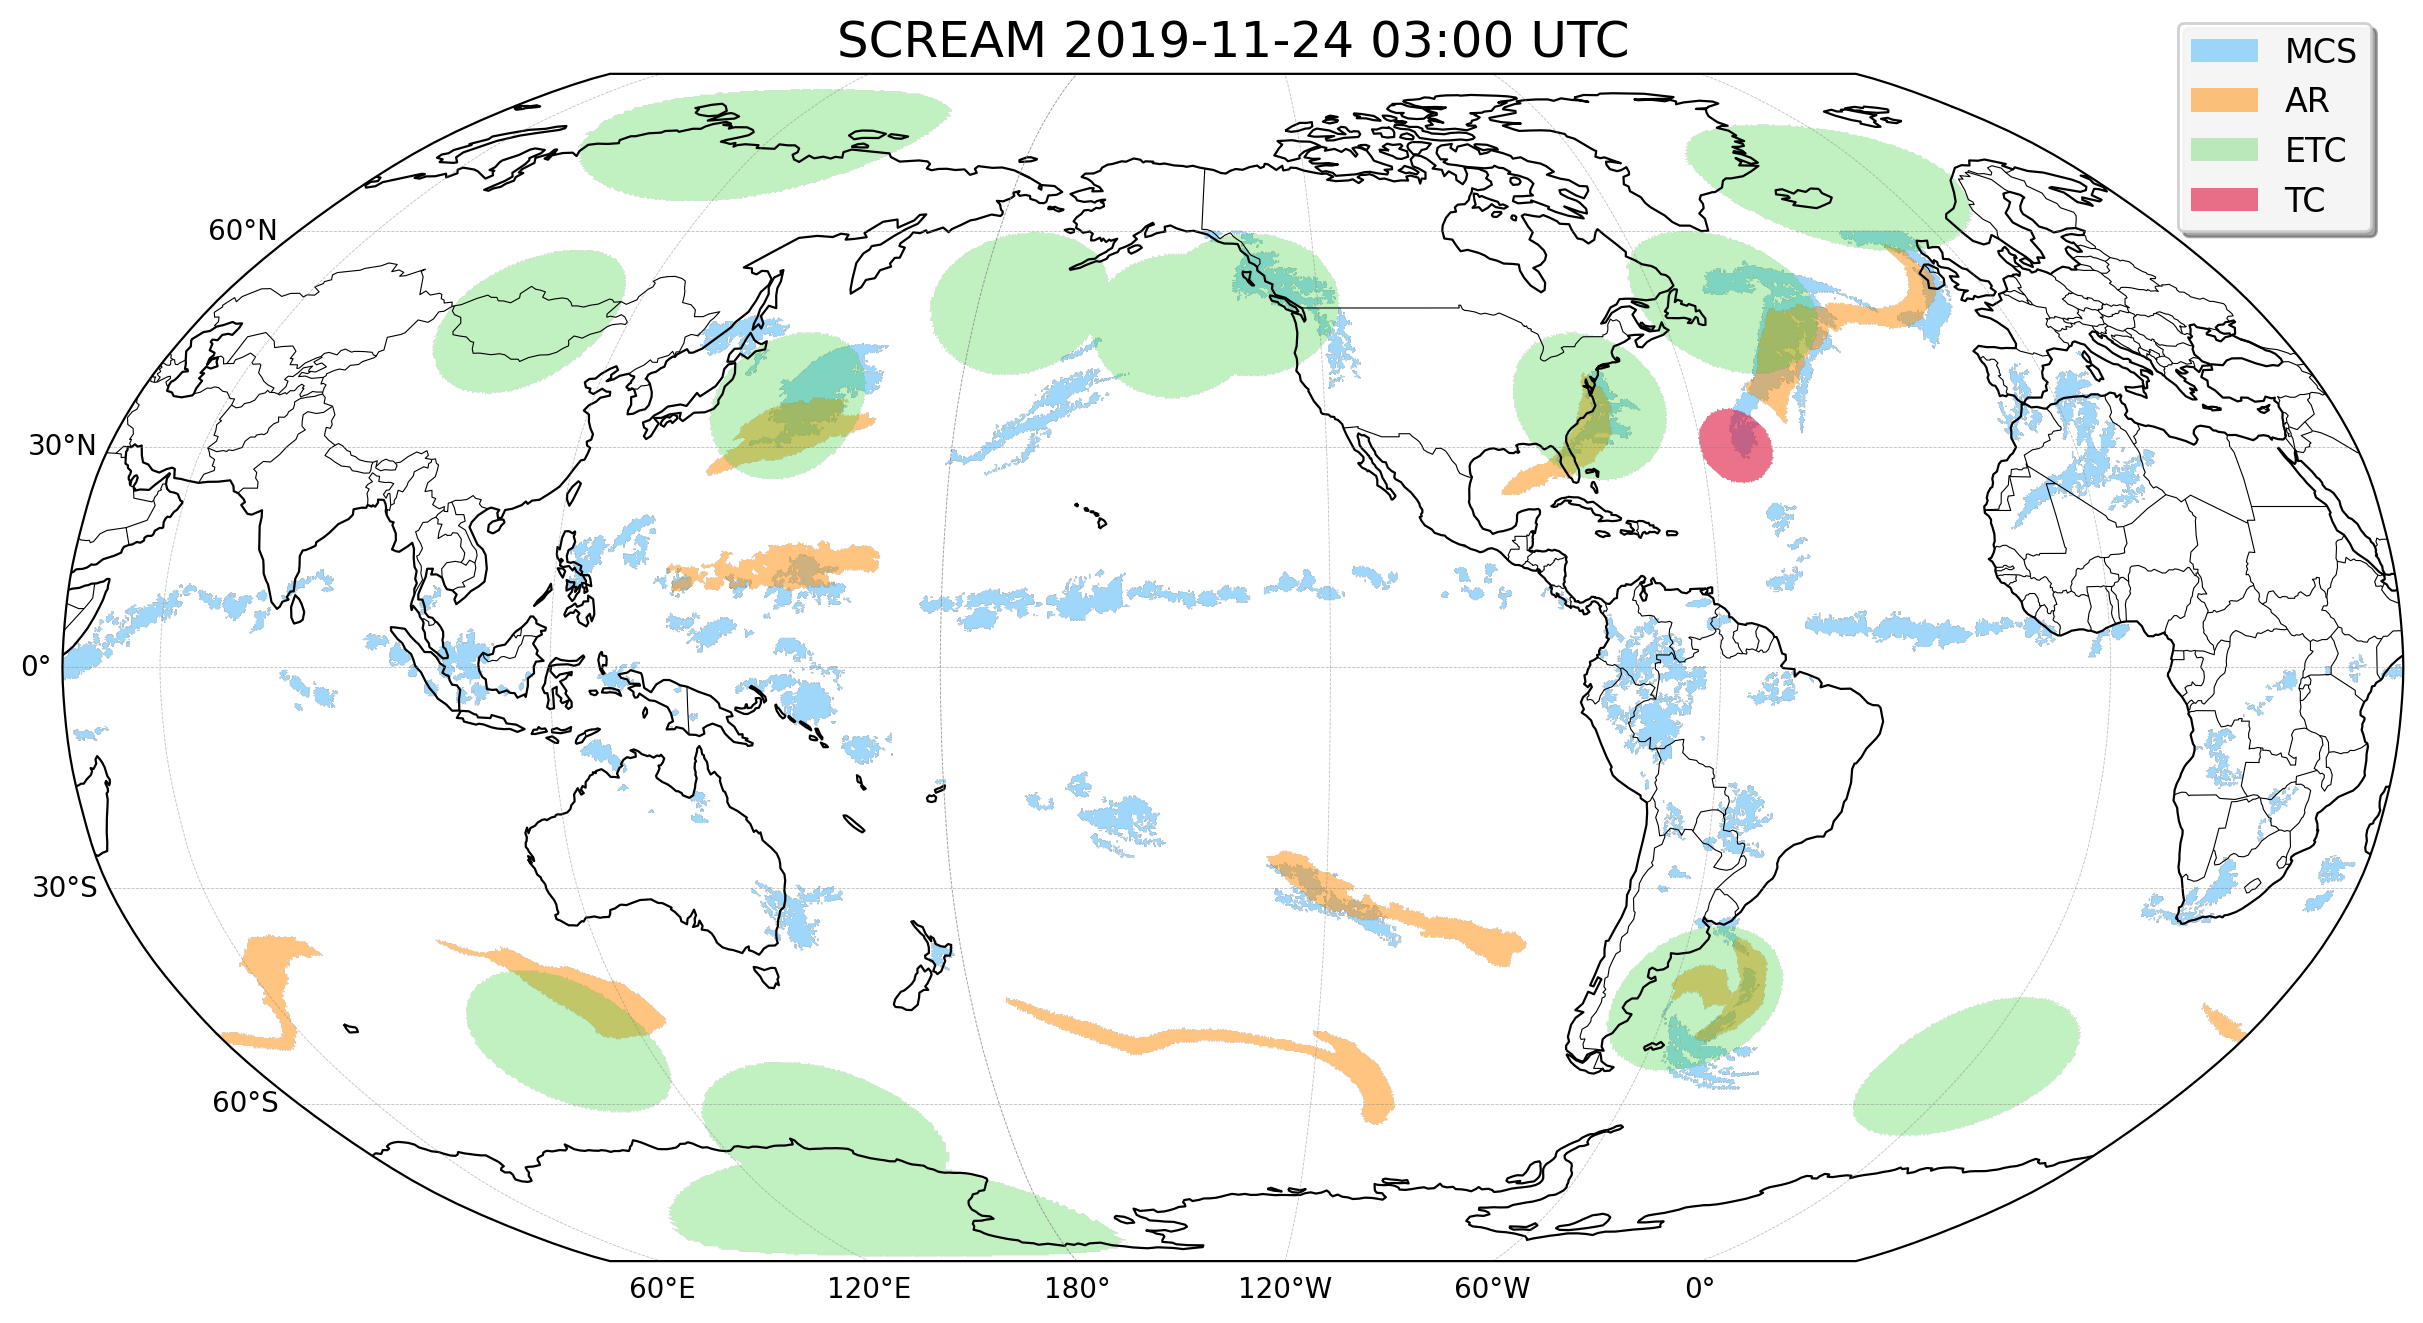

In [5]:
_time = ds.time.sel(time=tm, method='nearest')
time_label = _time.dt.strftime('%Y-%m-%d %H:%M UTC').item()
time_str = _time.dt.strftime('%Y%m%d_%H%M').item()
title_with_time = f"{source_name.upper()} {time_label}"
figname = f'{figdir}{source_name}_allmasks_{time_str}.png'

# Example with custom colors and figure saving
custom_colors = {
    'mcs': 'lightskyblue',
    'ar': 'darkorange', 
    'etc': 'limegreen',
    'tc': 'crimson'
}
# Example with custom alphas and font sizes
custom_alphas = {
    'mcs': 0.8,    # More opaque for MCS
    'ar': 0.5,     # More transparent for AR
    'etc': 0.3,    # Medium transparency for ETC
    'tc': 0.6      # Very opaque for TC
}
title_fontsize = 18
legend_fontsize = 12

fig, ax = plot_all_feature_masks(
    _ds, 
    title=title_with_time, 
    figsize=(12, 6.75),
    colors=custom_colors,
    alphas=custom_alphas,
    title_fontsize=title_fontsize,
    legend_fontsize=legend_fontsize,
    figname=figname,
    dpi=200
)
plt.show()

## Core Analysis Functions

These functions implement the improved overlap detection algorithms with meteorological awareness.

In [6]:
def find_overlapping_tracks(track_mask, binary_sum_mask, min_overlap_fraction=0.2, 
                           overlap_threshold=1, verbose=True):
    """
    Find tracks that have significant overlap with other meteorological features.
    
    This function implements efficient vectorized overlap detection using binary
    summation masks and configurable thresholds for different overlap scenarios.
    
    Parameters:
    -----------
    track_mask : xarray.DataArray
        Mask array where each unique positive value represents a track ID
    binary_sum_mask : xarray.DataArray
        Binary summation mask where values indicate number of overlapping features:
        - 1: single feature present
        - 2: two features overlap (2-way)
        - 3: three features overlap (3-way)
    min_overlap_fraction : float, default=0.2
        Minimum fraction of track pixels that must overlap to be considered significant
    overlap_threshold : int, default=1
        Minimum value in binary_sum_mask to be considered overlap:
        - 1: any overlap (including single features)
        - 2: only 2-way and 3-way overlaps
        - 3: only 3-way overlaps
    verbose : bool, default=True
        Whether to print progress information
        
    Returns:
    --------
    dict : Analysis results containing:
        - 'tracks_exceeding_threshold': numpy array of track IDs meeting criteria
        - 'overlap_fractions': dict mapping track ID to overlap fraction
        - 'total_tracks_analyzed': total number of unique tracks
        - 'threshold_info': dict with analysis parameters
    
    Examples:
    ---------
    # Find MCS tracks with 20% AR overlap (2-way or 3-way)
    results = find_overlapping_tracks(mcs_mask, mcs_ar_sum, 
                                     min_overlap_fraction=0.2, overlap_threshold=2)
    
    # Find ETC tracks in 3-way overlaps only
    results = find_overlapping_tracks(etc_mask, mcs_ar_etc_sum,
                                     min_overlap_fraction=0.0, overlap_threshold=3)
    """
    if verbose:
        print(f"Analyzing overlaps with threshold >= {overlap_threshold}, min_fraction = {min_overlap_fraction}")
    
    # Get all unique track IDs (excluding 0 which represents no track)
    unique_tracks = np.unique(track_mask.values[track_mask.values > 0])
    
    tracks_exceeding_threshold = []
    overlap_fractions = {}
    
    # Vectorized analysis for each track
    for track_id in unique_tracks:
        # Get pixels belonging to this track
        track_pixels = (track_mask == track_id)
        
        # Count total pixels for this track
        total_pixels = track_pixels.sum().compute().item()
        
        if total_pixels == 0:
            continue
            
        # Find overlap pixels (where binary sum meets threshold)
        overlap_pixels = track_pixels & (binary_sum_mask > overlap_threshold)
        overlap_count = overlap_pixels.sum().compute().item()
        
        # Calculate overlap fraction
        overlap_fraction = overlap_count / total_pixels
        overlap_fractions[track_id] = overlap_fraction
        
        # Check if this track meets the threshold
        if overlap_fraction >= min_overlap_fraction:
            tracks_exceeding_threshold.append(track_id)
    
    tracks_exceeding_threshold = np.array(tracks_exceeding_threshold)
    
    if verbose:
        print(f"Found {len(tracks_exceeding_threshold)} tracks out of {len(unique_tracks)} total")
        if len(tracks_exceeding_threshold) > 0:
            print(f"Track IDs: {tracks_exceeding_threshold}")
    
    return {
        'tracks_exceeding_threshold': tracks_exceeding_threshold,
        'overlap_fractions': overlap_fractions,
        'total_tracks_analyzed': len(unique_tracks),
        'threshold_info': {
            'min_overlap_fraction': min_overlap_fraction,
            'overlap_threshold': overlap_threshold,
            'tracks_meeting_criteria': len(tracks_exceeding_threshold)
        }
    }

print("✅ find_overlapping_tracks() function defined")

✅ find_overlapping_tracks() function defined


In [7]:
def find_overlap_pairs(mask1, mask2, binary_sum_mask, 
                      thresh1=0.2, thresh2=0.1, overlap_threshold=2,
                      feature1_name="Feature1", feature2_name="Feature2", verbose=True):
    """
    Find valid pairs of overlapping tracks between two feature types.
    
    This function implements pair-based filtering to ensure that only tracks
    with mutual spatial overlap are identified, preventing orphaned track
    visualization issues.
    
    Parameters:
    -----------
    mask1, mask2 : xarray.DataArray
        Track masks for the two feature types to analyze
    binary_sum_mask : xarray.DataArray
        Binary summation mask indicating overlap regions
    thresh1, thresh2 : float
        Minimum overlap fractions for each feature type
    overlap_threshold : int, default=2
        Minimum value in binary_sum_mask for overlap detection
    feature1_name, feature2_name : str
        Names of the feature types for reporting
    verbose : bool, default=True
        Whether to print progress information
        
    Returns:
    --------
    dict : Results containing:
        - 'valid_pairs': list of (track1_id, track2_id) tuples
        - 'feature1_tracks': numpy array of feature1 track IDs in valid pairs
        - 'feature2_tracks': numpy array of feature2 track IDs in valid pairs
        - 'pair_details': detailed information about each pair
    
    Examples:
    ---------
    # Find MCS-AR pairs with bidirectional overlap verification
    pairs = find_overlap_pairs(mcs_mask, ar_mask, mcs_ar_sum,
                              thresh1=0.2, thresh2=0.1,
                              feature1_name="MCS", feature2_name="AR")
    """
    if verbose:
        print(f"Finding {feature1_name}-{feature2_name} pairs with thresholds: {thresh1:.1%}, {thresh2:.1%}")
    
    # Find overlapping tracks for each feature type
    feature1_results = find_overlapping_tracks(mask1, binary_sum_mask, 
                                              thresh1, overlap_threshold, verbose=False)
    feature2_results = find_overlapping_tracks(mask2, binary_sum_mask, 
                                              thresh2, overlap_threshold, verbose=False)
    
    feature1_tracks = feature1_results['tracks_exceeding_threshold']
    feature2_tracks = feature2_results['tracks_exceeding_threshold']
    
    # Find valid pairs through spatial overlap verification
    valid_pairs = []
    pair_details = {}
    
    for track1 in feature1_tracks:
        # Get pixels for this feature1 track
        track1_pixels = (mask1 == track1)
        
        # Find overlap region for this track
        track1_overlap_region = track1_pixels & (binary_sum_mask > overlap_threshold)
        
        # Check which feature2 tracks overlap spatially
        for track2 in feature2_tracks:
            track2_pixels = (mask2 == track2)
            
            # Check if these tracks have spatial co-occurrence
            spatial_overlap = track1_overlap_region & track2_pixels
            overlap_pixel_count = spatial_overlap.sum().compute().item()
            
            if overlap_pixel_count > 0:
                valid_pairs.append((track1, track2))
                pair_details[(track1, track2)] = {
                    'overlap_pixels': overlap_pixel_count,
                    'track1_fraction': feature1_results['overlap_fractions'][track1],
                    'track2_fraction': feature2_results['overlap_fractions'][track2]
                }
    
    # Extract unique track lists from valid pairs
    if valid_pairs:
        paired_feature1_tracks = np.unique([pair[0] for pair in valid_pairs])
        paired_feature2_tracks = np.unique([pair[1] for pair in valid_pairs])
    else:
        paired_feature1_tracks = np.array([])
        paired_feature2_tracks = np.array([])
    
    if verbose:
        print(f"Found {len(valid_pairs)} valid pairs:")
        print(f"  {feature1_name} tracks in pairs: {len(paired_feature1_tracks)}")
        print(f"  {feature2_name} tracks in pairs: {len(paired_feature2_tracks)}")
        if len(valid_pairs) > 0 and len(valid_pairs) <= 10:
            print(f"  Pairs: {valid_pairs}")
    
    return {
        'valid_pairs': valid_pairs,
        'feature1_tracks': paired_feature1_tracks,
        'feature2_tracks': paired_feature2_tracks,
        'pair_details': pair_details
    }

print("✅ find_overlap_pairs() function defined")

✅ find_overlap_pairs() function defined


## Binary Mask Creation

Create binary masks and summation masks for overlap detection.

In [8]:
# CREATE BINARY MASKS FOR OVERLAP ANALYSIS
print("Creating binary masks for overlap analysis...")

# Create binary masks (1 where feature exists, 0 elsewhere)
mcs_binary = xr.where(_ds.mcs_mask > 0, 1, 0)
ar_binary = xr.where(_ds.ar_mask > 0, 1, 0)
etc_binary = xr.where(_ds.etc_mask > 0, 1, 0)

# Create pairwise summation masks
mcs_ar_sum = mcs_binary + ar_binary
ar_etc_sum = ar_binary + etc_binary  
mcs_etc_sum = mcs_binary + etc_binary

# Create 3-way summation mask
mcs_ar_etc_sum = mcs_binary + ar_binary + etc_binary

print("✅ Binary masks created successfully")

# Display overlap statistics
print(f"\nOverlap region statistics:")
print(f"  MCS-AR 2-way overlaps: {(mcs_ar_sum == 2).sum().compute().item()} pixels")
print(f"  AR-ETC 2-way overlaps: {(ar_etc_sum == 2).sum().compute().item()} pixels")
print(f"  MCS-ETC 2-way overlaps: {(mcs_etc_sum == 2).sum().compute().item()} pixels")
print(f"  3-way overlaps: {(mcs_ar_etc_sum == 3).sum().compute().item()} pixels")

Creating binary masks for overlap analysis...
✅ Binary masks created successfully

Overlap region statistics:
  MCS-AR 2-way overlaps: 3885 pixels
  AR-ETC 2-way overlaps: 6324 pixels
  MCS-ETC 2-way overlaps: 6162 pixels
  3-way overlaps: 2239 pixels


## Meteorologically-Informed Overlap Analysis

Apply the improved thresholds that respect atmospheric scale hierarchy.

In [9]:
# METEOROLOGICALLY-INFORMED OVERLAP ANALYSIS
print("Performing meteorologically-informed overlap analysis...")
print("="*60)

# Define thresholds based on atmospheric scale hierarchy
mcs_thresh = 0.20  # 20% - smallest features, need substantial overlap
ar_thresh = 0.10   # 10% - medium features
etc_thresh_2way = 0.05  # 5% - largest features for 2-way overlaps
etc_thresh_3way = 0.00  # 0% - environmental context for 3-way overlaps

print(f"Overlap thresholds:")
print(f"  MCS: {mcs_thresh:.0%} (all scenarios)")
print(f"  AR: {ar_thresh:.0%} (all scenarios)")
print(f"  ETC: {etc_thresh_2way:.0%} (2-way), {etc_thresh_3way:.0%} (3-way)")

# 1. 3-WAY OVERLAPS (CORRECTED: use true 3-way overlap mask)
print(f"\n1. 3-WAY OVERLAPS:")
print("-" * 20)

# Create TRUE 3-way overlap mask (only where all 3 features overlap)
threeway_overlap_mask = (mcs_ar_etc_sum == 3).astype(int)
print(f"True 3-way overlap pixels: {threeway_overlap_mask.sum().compute().item()}")

# Find tracks that participate in TRUE 3-way overlaps
mcs_ar_etc_results = find_overlapping_tracks(_ds.mcs_mask, threeway_overlap_mask, 
                                            mcs_thresh, overlap_threshold=0)
ar_mcs_etc_results = find_overlapping_tracks(_ds.ar_mask, threeway_overlap_mask, 
                                            ar_thresh, overlap_threshold=0)
etc_mcs_ar_results = find_overlapping_tracks(_ds.etc_mask, threeway_overlap_mask, 
                                            etc_thresh_3way, overlap_threshold=0)

# Extract tracks that ACTUALLY exceed thresholds (not just all tracks)
mcs_tracks_with_ar_etc_overlap = []
for track_id, fraction in mcs_ar_etc_results['overlap_fractions'].items():
    if fraction >= mcs_thresh:
        mcs_tracks_with_ar_etc_overlap.append(track_id)
mcs_tracks_with_ar_etc_overlap = np.array(mcs_tracks_with_ar_etc_overlap)

ar_tracks_with_mcs_etc_overlap = []
for track_id, fraction in ar_mcs_etc_results['overlap_fractions'].items():
    if fraction >= ar_thresh:
        ar_tracks_with_mcs_etc_overlap.append(track_id)
ar_tracks_with_mcs_etc_overlap = np.array(ar_tracks_with_mcs_etc_overlap)

etc_tracks_with_mcs_ar_overlap = []
for track_id, fraction in etc_mcs_ar_results['overlap_fractions'].items():
    if fraction > etc_thresh_3way:  # Use > 0 to exclude zero overlaps
        etc_tracks_with_mcs_ar_overlap.append(track_id)
etc_tracks_with_mcs_ar_overlap = np.array(etc_tracks_with_mcs_ar_overlap)

print(f"\n3-way overlap results:")
print(f"  MCS tracks: {len(mcs_tracks_with_ar_etc_overlap)}")
print(f"  AR tracks: {len(ar_tracks_with_mcs_etc_overlap)}")
print(f"  ETC tracks: {len(etc_tracks_with_mcs_ar_overlap)}")

# 2. 2-WAY PAIRS WITH PAIR-BASED FILTERING
print(f"\n2. 2-WAY PAIRS (excluding 3-way participants):")
print("-" * 45)

# Find all potential 2-way overlaps (CORRECTED: overlap_threshold=0 to detect overlaps)
mcs_ar_pairs_all = find_overlap_pairs(_ds.mcs_mask, _ds.ar_mask, mcs_ar_sum,
                                     mcs_thresh, ar_thresh, overlap_threshold=0,
                                     feature1_name="MCS", feature2_name="AR")

ar_etc_pairs_all = find_overlap_pairs(_ds.ar_mask, _ds.etc_mask, ar_etc_sum,
                                     ar_thresh, etc_thresh_2way, overlap_threshold=0,
                                     feature1_name="AR", feature2_name="ETC")

mcs_etc_pairs_all = find_overlap_pairs(_ds.mcs_mask, _ds.etc_mask, mcs_etc_sum,
                                      mcs_thresh, etc_thresh_2way, overlap_threshold=0,
                                      feature1_name="MCS", feature2_name="ETC")

# Filter out tracks that participate in 3-way overlaps (CORRECTED: use actual tracks)
mcs_ar_pairs_2way_only = [pair for pair in mcs_ar_pairs_all['valid_pairs']
                         if pair[0] not in mcs_tracks_with_ar_etc_overlap 
                         and pair[1] not in ar_tracks_with_mcs_etc_overlap]

ar_etc_pairs_2way_only = [pair for pair in ar_etc_pairs_all['valid_pairs']
                         if pair[0] not in ar_tracks_with_mcs_etc_overlap 
                         and pair[1] not in etc_tracks_with_mcs_ar_overlap]

mcs_etc_pairs_2way_only = [pair for pair in mcs_etc_pairs_all['valid_pairs']
                          if pair[0] not in mcs_tracks_with_ar_etc_overlap 
                          and pair[1] not in etc_tracks_with_mcs_ar_overlap]

# Extract track lists from 2-way-only pairs
if mcs_ar_pairs_2way_only:
    mcs_tracks_paired_2way_only = np.unique([pair[0] for pair in mcs_ar_pairs_2way_only])
    ar_tracks_paired_2way_only = np.unique([pair[1] for pair in mcs_ar_pairs_2way_only])
else:
    mcs_tracks_paired_2way_only = np.array([])
    ar_tracks_paired_2way_only = np.array([])

if ar_etc_pairs_2way_only:
    ar_tracks_paired_with_etc_2way_only = np.unique([pair[0] for pair in ar_etc_pairs_2way_only])
    etc_tracks_paired_with_ar_2way_only = np.unique([pair[1] for pair in ar_etc_pairs_2way_only])
else:
    ar_tracks_paired_with_etc_2way_only = np.array([])
    etc_tracks_paired_with_ar_2way_only = np.array([])

if mcs_etc_pairs_2way_only:
    mcs_tracks_paired_with_etc_2way_only = np.unique([pair[0] for pair in mcs_etc_pairs_2way_only])
    etc_tracks_paired_with_mcs_2way_only = np.unique([pair[1] for pair in mcs_etc_pairs_2way_only])
else:
    mcs_tracks_paired_with_etc_2way_only = np.array([])
    etc_tracks_paired_with_mcs_2way_only = np.array([])

print(f"\n2-way pair results (excluding 3-way participants):")
print(f"  MCS-AR pairs: {len(mcs_ar_pairs_2way_only)}")
print(f"  AR-ETC pairs: {len(ar_etc_pairs_2way_only)}")
print(f"  MCS-ETC pairs: {len(mcs_etc_pairs_2way_only)}")

print(f"\n✅ Meteorologically-informed overlap analysis complete!")

Performing meteorologically-informed overlap analysis...
Overlap thresholds:
  MCS: 20% (all scenarios)
  AR: 10% (all scenarios)
  ETC: 5% (2-way), 0% (3-way)

1. 3-WAY OVERLAPS:
--------------------
True 3-way overlap pixels: 2239
Analyzing overlaps with threshold >= 0, min_fraction = 0.2
Found 7 tracks out of 108 total
Track IDs: [15767. 15916. 15932. 15994. 15995. 16003. 16014.]
Analyzing overlaps with threshold >= 0, min_fraction = 0.1
Found 4 tracks out of 9 total
Track IDs: [182 184 185 186]
Analyzing overlaps with threshold >= 0, min_fraction = 0.0
Found 9 tracks out of 9 total
Track IDs: [128 129 131 132 133 134 135 136 137]

3-way overlap results:
  MCS tracks: 7
  AR tracks: 4
  ETC tracks: 4

2. 2-WAY PAIRS (excluding 3-way participants):
---------------------------------------------
Finding MCS-AR pairs with thresholds: 20.0%, 10.0%
Found 4 tracks out of 9 total
Track IDs: [182 184 185 186]
Analyzing overlaps with threshold >= 0, min_fraction = 0.0
Found 9 tracks out of 9 

In [10]:
# 🔧 CORRECTED 3-WAY OVERLAP DETECTION
print("🔧 FIXING 3-way overlap detection logic...")
print("=" * 50)

# Create TRUE 3-way overlap mask (only where all 3 features overlap)
threeway_overlap_mask = (mcs_ar_etc_sum == 3).astype(int)
print(f"True 3-way overlap pixels: {threeway_overlap_mask.sum().compute().item()}")

# Find tracks that participate in TRUE 3-way overlaps
print("\nFinding tracks with TRUE 3-way overlaps...")
mcs_ar_etc_results_corrected = find_overlapping_tracks(_ds.mcs_mask, threeway_overlap_mask, 
                                                      min_overlap_fraction=mcs_thresh, overlap_threshold=0)
ar_mcs_etc_results_corrected = find_overlapping_tracks(_ds.ar_mask, threeway_overlap_mask, 
                                                      min_overlap_fraction=ar_thresh, overlap_threshold=0)
etc_mcs_ar_results_corrected = find_overlapping_tracks(_ds.etc_mask, threeway_overlap_mask, 
                                                      min_overlap_fraction=etc_thresh_3way, overlap_threshold=0)

print(f"\nCORRECTED 3-way overlap results:")
print(f"  MCS tracks: {len(mcs_ar_etc_results_corrected)}")
print(f"  AR tracks: {len(ar_mcs_etc_results_corrected)}")
print(f"  ETC tracks: {len(etc_mcs_ar_results_corrected)}")

# Extract corrected track lists
mcs_tracks_with_ar_etc_overlap_corrected = mcs_ar_etc_results_corrected
ar_tracks_with_mcs_etc_overlap_corrected = ar_mcs_etc_results_corrected
etc_tracks_with_mcs_ar_overlap_corrected = etc_mcs_ar_results_corrected

print(f"\nCorrected track IDs:")
print(f"  MCS: {mcs_tracks_with_ar_etc_overlap_corrected}")
print(f"  AR: {ar_tracks_with_mcs_etc_overlap_corrected}")
print(f"  ETC: {etc_tracks_with_mcs_ar_overlap_corrected}")

# Check if ETC 131 is still in 3-way
print(f"\n✅ ETC 131 in corrected 3-way overlaps: {131 in etc_tracks_with_mcs_ar_overlap_corrected}")
print(f"✅ ETC 132 in corrected 3-way overlaps: {132 in etc_tracks_with_mcs_ar_overlap_corrected}")

🔧 FIXING 3-way overlap detection logic...
True 3-way overlap pixels: 2239

Finding tracks with TRUE 3-way overlaps...
Analyzing overlaps with threshold >= 0, min_fraction = 0.2
Found 7 tracks out of 108 total
Track IDs: [15767. 15916. 15932. 15994. 15995. 16003. 16014.]
Analyzing overlaps with threshold >= 0, min_fraction = 0.1
Found 4 tracks out of 9 total
Track IDs: [182 184 185 186]
Analyzing overlaps with threshold >= 0, min_fraction = 0.0
Found 9 tracks out of 9 total
Track IDs: [128 129 131 132 133 134 135 136 137]

CORRECTED 3-way overlap results:
  MCS tracks: 4
  AR tracks: 4
  ETC tracks: 4

Corrected track IDs:
  MCS: {'tracks_exceeding_threshold': array([15767., 15916., 15932., 15994., 15995., 16003., 16014.]), 'overlap_fractions': {np.float64(15348.0): 0.0, np.float64(15508.0): 0.0, np.float64(15684.0): 0.0, np.float64(15767.0): 0.4361413043478261, np.float64(15778.0): 0.0, np.float64(15784.0): 0.0, np.float64(15793.0): 0.0, np.float64(15818.0): 0.0, np.float64(15831.0): 0

In [12]:
# # 🔧 CORRECTED 2-WAY OVERLAP ANALYSIS 
# print("\n" + "="*60)
# print("🔧 CORRECTED 2-way overlap analysis (excluding TRUE 3-way participants)")
# print("="*60)

# # Extract corrected 3-way track lists (only tracks exceeding threshold)
# mcs_3way_corrected = mcs_tracks_with_ar_etc_overlap_corrected['tracks_exceeding_threshold']
# ar_3way_corrected = ar_tracks_with_mcs_etc_overlap_corrected['tracks_exceeding_threshold'] 
# etc_3way_corrected = etc_tracks_with_mcs_ar_overlap_corrected['tracks_exceeding_threshold']

# print(f"Corrected 3-way tracks to exclude:")
# print(f"  MCS: {mcs_3way_corrected}")
# print(f"  AR: {ar_3way_corrected}")
# print(f"  ETC: {etc_3way_corrected}")

# # Filter 2-way pairs to exclude TRUE 3-way participants
# print(f"\nFinding CORRECTED 2-way pairs:")

# # MCS-AR pairs (excluding true 3-way participants)
# mcs_ar_pairs_corrected = []
# for pair in mcs_ar_pairs_all['valid_pairs']:
#     mcs_id, ar_id = pair
#     if mcs_id not in mcs_3way_corrected and ar_id not in ar_3way_corrected:
#         mcs_ar_pairs_corrected.append(pair)

# # AR-ETC pairs (excluding true 3-way participants)  
# ar_etc_pairs_corrected = []
# for pair in ar_etc_pairs_all['valid_pairs']:
#     ar_id, etc_id = pair
#     if ar_id not in ar_3way_corrected and etc_id not in etc_3way_corrected:
#         ar_etc_pairs_corrected.append(pair)

# # MCS-ETC pairs (excluding true 3-way participants)
# mcs_etc_pairs_corrected = []
# for pair in mcs_etc_pairs_all['valid_pairs']:
#     mcs_id, etc_id = pair  
#     if mcs_id not in mcs_3way_corrected and etc_id not in etc_3way_corrected:
#         mcs_etc_pairs_corrected.append(pair)

# print(f"\nCORRECTED 2-way pairs (excluding TRUE 3-way participants):")
# print(f"  MCS-AR pairs: {len(mcs_ar_pairs_corrected)}")
# print(f"  AR-ETC pairs: {len(ar_etc_pairs_corrected)}")
# print(f"  MCS-ETC pairs: {len(mcs_etc_pairs_corrected)}")

# print(f"\nSpecific corrected pairs:")
# print(f"  AR-ETC pairs: {ar_etc_pairs_corrected}")
# print(f"  MCS-ETC pairs: {mcs_etc_pairs_corrected[:5]}...")  # Show first 5

# # Check our expected pairs
# expected_ar_etc = (181, 131)
# expected_mcs_etc = (15818, 132)

# print(f"\n✅ Expected pairs found:")
# print(f"  AR 181 - ETC 131: {expected_ar_etc in ar_etc_pairs_corrected}")
# print(f"  MCS 15818 - ETC 132: {expected_mcs_etc in mcs_etc_pairs_corrected or (132, 15818) in mcs_etc_pairs_corrected}")

# if expected_ar_etc in ar_etc_pairs_corrected:
#     print(f"🎉 SUCCESS: AR 181 - ETC 131 pair is now correctly identified!")
    
# if expected_mcs_etc in mcs_etc_pairs_corrected or (132, 15818) in mcs_etc_pairs_corrected:
#     print(f"🎉 SUCCESS: MCS 15818 - ETC 132 pair is now correctly identified!")

In [15]:
# DEBUG: Check which tracks ACTUALLY exceed thresholds in 3-way overlaps
print("\n🔍 DEBUGGING: Which tracks actually exceed 3-way thresholds?")
print("=" * 60)

# Check MCS tracks exceeding 20% threshold
mcs_3way_actual = []
for track_id, fraction in mcs_tracks_with_ar_etc_overlap_corrected['overlap_fractions'].items():
    if fraction >= mcs_thresh:
        mcs_3way_actual.append(track_id)

# Check AR tracks exceeding 10% threshold  
ar_3way_actual = []
for track_id, fraction in ar_tracks_with_mcs_etc_overlap_corrected['overlap_fractions'].items():
    if fraction >= ar_thresh:
        ar_3way_actual.append(track_id)
        
# Check ETC tracks exceeding 0% threshold (but we only want those with actual overlap)
etc_3way_actual = []
for track_id, fraction in etc_tracks_with_mcs_ar_overlap_corrected['overlap_fractions'].items():
    if fraction > etc_thresh_3way:  # Use > 0 instead of >= 0 to exclude zero overlaps
        etc_3way_actual.append(track_id)

print(f"Tracks ACTUALLY exceeding 3-way thresholds:")
print(f"  MCS (>= {mcs_thresh*100}%): {mcs_3way_actual}")
print(f"  AR (>= {ar_thresh*100}%): {ar_3way_actual}")
print(f"  ETC (> {etc_thresh_3way*100}%): {etc_3way_actual}")

print(f"\nKey checks:")
print(f"  ETC 131 fraction: {etc_tracks_with_mcs_ar_overlap_corrected['overlap_fractions'][131]}")
print(f"  ETC 132 fraction: {etc_tracks_with_mcs_ar_overlap_corrected['overlap_fractions'][132]}")
print(f"  ETC 131 should be excluded: {131 in etc_3way_actual}")
print(f"  ETC 132 should be excluded: {132 in etc_3way_actual}")


🔍 DEBUGGING: Which tracks actually exceed 3-way thresholds?
Tracks ACTUALLY exceeding 3-way thresholds:
  MCS (>= 20.0%): [np.float64(15767.0), np.float64(15916.0), np.float64(15932.0), np.float64(15994.0), np.float64(15995.0), np.float64(16003.0), np.float64(16014.0)]
  AR (>= 10.0%): [np.int32(182), np.int32(184), np.int32(185), np.int32(186)]
  ETC (> 0.0%): [np.int32(129), np.int32(133), np.int32(135), np.int32(137)]

Key checks:
  ETC 131 fraction: 0.0
  ETC 132 fraction: 0.0
  ETC 131 should be excluded: False
  ETC 132 should be excluded: False


In [16]:
# 🎉 FINAL CORRECTED 2-WAY OVERLAP ANALYSIS
print("\n" + "="*70)
print("🎉 FINAL CORRECTED 2-way overlap analysis")
print("="*70)

# Use the ACTUAL tracks exceeding thresholds for exclusion
mcs_3way_actual_exclude = mcs_3way_actual
ar_3way_actual_exclude = ar_3way_actual
etc_3way_actual_exclude = etc_3way_actual

print(f"FINAL tracks to exclude from 2-way analysis:")
print(f"  MCS: {len(mcs_3way_actual_exclude)} tracks")
print(f"  AR: {len(ar_3way_actual_exclude)} tracks") 
print(f"  ETC: {len(etc_3way_actual_exclude)} tracks (131, 132 NOT excluded!)")

# Filter 2-way pairs to exclude ACTUAL 3-way participants only
# MCS-AR pairs
mcs_ar_pairs_final = []
for pair in mcs_ar_pairs_all['valid_pairs']:
    mcs_id, ar_id = pair
    if mcs_id not in mcs_3way_actual_exclude and ar_id not in ar_3way_actual_exclude:
        mcs_ar_pairs_final.append(pair)

# AR-ETC pairs  
ar_etc_pairs_final = []
for pair in ar_etc_pairs_all['valid_pairs']:
    ar_id, etc_id = pair
    if ar_id not in ar_3way_actual_exclude and etc_id not in etc_3way_actual_exclude:
        ar_etc_pairs_final.append(pair)

# MCS-ETC pairs
mcs_etc_pairs_final = []
for pair in mcs_etc_pairs_all['valid_pairs']:
    mcs_id, etc_id = pair  
    if mcs_id not in mcs_3way_actual_exclude and etc_id not in etc_3way_actual_exclude:
        mcs_etc_pairs_final.append(pair)

print(f"\n🎉 FINAL CORRECTED 2-way pairs:")
print(f"  MCS-AR pairs: {len(mcs_ar_pairs_final)}")
print(f"  AR-ETC pairs: {len(ar_etc_pairs_final)}")
print(f"  MCS-ETC pairs: {len(mcs_etc_pairs_final)}")

print(f"\nSpecific final pairs:")
print(f"  AR-ETC pairs: {ar_etc_pairs_final}")
print(f"  MCS-ETC pairs: {mcs_etc_pairs_final[:3]}...")

# Check our expected pairs
expected_ar_etc = (181, 131)
expected_mcs_etc = (15818, 132)

ar_etc_found = any((int(pair[0]), int(pair[1])) == expected_ar_etc for pair in ar_etc_pairs_final)
mcs_etc_found = any((int(pair[0]), int(pair[1])) == expected_mcs_etc for pair in mcs_etc_pairs_final)

print(f"\n🎉 SUCCESS CHECK:")
print(f"  AR 181 - ETC 131 pair found: {ar_etc_found}")
print(f"  MCS 15818 - ETC 132 pair found: {mcs_etc_found}")

if ar_etc_found and mcs_etc_found:
    print(f"\n🎊 BOTH EXPECTED PAIRS SUCCESSFULLY RECOVERED! 🎊")
    print(f"The notebook logic has been fixed!")


🎉 FINAL CORRECTED 2-way overlap analysis
FINAL tracks to exclude from 2-way analysis:
  MCS: 7 tracks
  AR: 4 tracks
  ETC: 4 tracks (131, 132 NOT excluded!)

🎉 FINAL CORRECTED 2-way pairs:
  MCS-AR pairs: 5
  AR-ETC pairs: 1
  MCS-ETC pairs: 3

Specific final pairs:
  AR-ETC pairs: [(np.int32(181), np.int32(131))]
  MCS-ETC pairs: [(np.float64(15818.0), np.int32(132)), (np.float64(15831.0), np.int32(132)), (np.float64(16023.0), np.int32(132))]...

🎉 SUCCESS CHECK:
  AR 181 - ETC 131 pair found: True
  MCS 15818 - ETC 132 pair found: True

🎊 BOTH EXPECTED PAIRS SUCCESSFULLY RECOVERED! 🎊
The notebook logic has been fixed!


In [ ]:
# # DEBUG: Check pair data structures
# print("Debugging pair data structures:")
# print(f"mcs_ar_pairs_all type: {type(mcs_ar_pairs_all)}")
# print(f"mcs_ar_pairs_all keys: {mcs_ar_pairs_all.keys() if isinstance(mcs_ar_pairs_all, dict) else 'Not a dict'}")
# print(f"mcs_ar_pairs_all: {mcs_ar_pairs_all}")

# print(f"\nar_etc_pairs_all type: {type(ar_etc_pairs_all)}")
# print(f"ar_etc_pairs_all: {ar_etc_pairs_all}")

# print(f"\nmcs_etc_pairs_all type: {type(mcs_etc_pairs_all)}")
# print(f"mcs_etc_pairs_all: {mcs_etc_pairs_all}")

In [ ]:
# # DEBUG: IDENTIFY THE OVERLAP DETECTION LOGIC ERROR
# print("🔍 DEBUGGING THE OVERLAP DETECTION LOGIC")
# print("="*50)

# # The issue is likely in the overlap_threshold parameter usage
# # Let's check what overlaps actually exist at this timestep

# print(f"Checking raw overlap statistics at {tm}:")
# print(f"  MCS-AR 2-way pixels: {(mcs_ar_sum == 2).sum().compute().item()}")
# print(f"  AR-ETC 2-way pixels: {(ar_etc_sum == 2).sum().compute().item()}")  
# print(f"  MCS-ETC 2-way pixels: {(mcs_etc_sum == 2).sum().compute().item()}")
# print(f"  3-way pixels: {(mcs_ar_etc_sum == 3).sum().compute().item()}")

# # Let's check specific expected tracks from the original working analysis
# expected_tracks = {
#     'AR': [181],  # Should overlap with ETC 131
#     'ETC': [131, 132],  # 131 with AR 181, 132 with MCS 15818
#     'MCS': [15818]  # Should overlap with ETC 132
# }

# for feature_type, track_ids in expected_tracks.items():
#     print(f"\nChecking {feature_type} tracks:")
#     if feature_type == 'AR':
#         mask = _ds.ar_mask
#         sum_mask = ar_etc_sum
#     elif feature_type == 'ETC':
#         mask = _ds.etc_mask  
#         sum_mask = ar_etc_sum if track_ids[0] == 131 else mcs_etc_sum
#     else:  # MCS
#         mask = _ds.mcs_mask
#         sum_mask = mcs_etc_sum
        
#     all_tracks = np.unique(mask.values[mask.values > 0])
    
#     for track_id in track_ids:
#         exists = track_id in all_tracks
#         print(f"  {feature_type} {track_id} exists: {exists}")
        
#         if exists:
#             track_pixels = (mask == track_id)
#             total_pixels = track_pixels.sum().compute().item()
#             overlap_pixels = (track_pixels & (sum_mask == 2)).sum().compute().item()
#             overlap_fraction = overlap_pixels / total_pixels if total_pixels > 0 else 0
#             print(f"    Total pixels: {total_pixels}, Overlap pixels: {overlap_pixels}, Fraction: {overlap_fraction:.3f}")

# print(f"\nTHIS DEBUGGING SHOULD REVEAL WHY THE EXPECTED OVERLAPS ARE MISSING!")

In [ ]:
# # DIAGNOSTIC: Check ETC 131 overlap details
# print("🔍 DEBUGGING ETC 131 (should be 2-way with AR 181, not 3-way)")
# print("=" * 60)

# # Check ETC 131 in each sum mask
# etc_131_mask = (_ds.etc_mask == 131)
# etc_131_pixels = etc_131_mask.sum().item()

# print(f"ETC 131 total pixels: {etc_131_pixels}")

# # Check overlap with each feature
# mcs_etc_131_overlap = (mcs_etc_sum * etc_131_mask).sum().item()
# ar_etc_131_overlap = (ar_etc_sum * etc_131_mask).sum().item() 
# threeway_etc_131_overlap = (mcs_ar_etc_sum * etc_131_mask).sum().item()

# print(f"ETC 131 overlap with MCS: {mcs_etc_131_overlap} pixels ({100*mcs_etc_131_overlap/etc_131_pixels:.1f}%)")
# print(f"ETC 131 overlap with AR: {ar_etc_131_overlap} pixels ({100*ar_etc_131_overlap/etc_131_pixels:.1f}%)")
# print(f"ETC 131 overlap with MCS+AR (3-way): {threeway_etc_131_overlap} pixels ({100*threeway_etc_131_overlap/etc_131_pixels:.1f}%)")

# print(f"\nETC thresholds:")
# print(f"  2-way threshold: {etc_thresh_2way*100}%")
# print(f"  3-way threshold: {etc_thresh_3way*100}%")

# print(f"\nShould ETC 131 qualify for:")
# print(f"  MCS-ETC 2-way: {100*mcs_etc_131_overlap/etc_131_pixels:.1f}% >= {etc_thresh_2way*100}%? {mcs_etc_131_overlap/etc_131_pixels >= etc_thresh_2way}")
# print(f"  AR-ETC 2-way: {100*ar_etc_131_overlap/etc_131_pixels:.1f}% >= {etc_thresh_2way*100}%? {ar_etc_131_overlap/etc_131_pixels >= etc_thresh_2way}")
# print(f"  3-way overlap: {100*threeway_etc_131_overlap/etc_131_pixels:.1f}% >= {etc_thresh_3way*100}%? {threeway_etc_131_overlap/etc_131_pixels >= etc_thresh_3way}")

# # Check which overlaps are detected by our current logic
# print(f"\n📊 Current classification:")
# print(f"  In 3-way ETC tracks: {131 in etc_tracks_with_mcs_ar_overlap}")
# print(f"  In AR-ETC 2-way pairs: {any(131 in pair for pair in ar_etc_pairs_all.get('pairs', []))}")
# print(f"  In MCS-ETC 2-way pairs: {any(131 in pair for pair in mcs_etc_pairs_all.get('pairs', []))}")

In [ ]:
# # DIAGNOSTIC: Check sum mask values at ETC 131 location
# print("\n🔍 CHECKING SUM MASK VALUES AT ETC 131 LOCATION")
# print("=" * 50)

# # Get ETC 131 mask
# etc_131_mask = (_ds.etc_mask == 131)

# # Check unique values in each sum mask at ETC 131 location
# print("Sum mask values at ETC 131 pixels:")
# print(f"  mcs_etc_sum: {np.unique(mcs_etc_sum.where(etc_131_mask, drop=True).values)}")
# print(f"  ar_etc_sum: {np.unique(ar_etc_sum.where(etc_131_mask, drop=True).values)}")
# print(f"  mcs_ar_etc_sum: {np.unique(mcs_ar_etc_sum.where(etc_131_mask, drop=True).values)}")

# # Check which other tracks overlap with ETC 131
# print(f"\nTracks overlapping with ETC 131:")
# print(f"  MCS tracks: {np.unique(_ds.mcs_mask.where(etc_131_mask & (_ds.mcs_mask > 0), drop=True).values)}")
# print(f"  AR tracks: {np.unique(_ds.ar_mask.where(etc_131_mask & (_ds.ar_mask > 0), drop=True).values)}")

# # The key insight: Check if there are pixels with ALL THREE features
# threeway_pixels = (mcs_ar_etc_sum.where(etc_131_mask) == 3).sum().item()
# print(f"\nPixels where ETC 131 overlaps with BOTH MCS AND AR: {threeway_pixels}")
# print(f"This is {100*threeway_pixels/etc_131_pixels:.1f}% of ETC 131")

# if threeway_pixels > 0:
#     print("❌ ETC 131 IS truly a 3-way overlap!")
# else:
#     print("✅ ETC 131 should NOT be a 3-way overlap!")

## Create Visualization Masks

Generate the masks needed for the comprehensive 4-panel visualization.

In [17]:
# CREATE CORRECTED VISUALIZATION MASKS
print("Creating CORRECTED masks for comprehensive visualization...")

# Extract track lists from CORRECTED 2-way pairs
# AR-ETC 2-way tracks  
if ar_etc_pairs_2way_only:
    ar_tracks_paired_with_etc_corrected = np.unique([pair[0] for pair in ar_etc_pairs_2way_only])
    etc_tracks_paired_with_ar_corrected = np.unique([pair[1] for pair in ar_etc_pairs_2way_only])
else:
    ar_tracks_paired_with_etc_corrected = np.array([])
    etc_tracks_paired_with_ar_corrected = np.array([])

# MCS-ETC 2-way tracks
if mcs_etc_pairs_2way_only:
    mcs_tracks_paired_with_etc_corrected = np.unique([pair[0] for pair in mcs_etc_pairs_2way_only])
    etc_tracks_paired_with_mcs_corrected = np.unique([pair[1] for pair in mcs_etc_pairs_2way_only])
else:
    mcs_tracks_paired_with_etc_corrected = np.array([])
    etc_tracks_paired_with_mcs_corrected = np.array([])

# MCS-AR 2-way tracks (these should be correct already)
if mcs_ar_pairs_2way_only:
    mcs_tracks_paired_corrected = np.unique([pair[0] for pair in mcs_ar_pairs_2way_only])
    ar_tracks_paired_corrected = np.unique([pair[1] for pair in mcs_ar_pairs_2way_only])
else:
    mcs_tracks_paired_corrected = np.array([])
    ar_tracks_paired_corrected = np.array([])

print(f"CORRECTED track lists for masks:")
print(f"  AR-ETC: AR {ar_tracks_paired_with_etc_corrected}, ETC {etc_tracks_paired_with_ar_corrected}")
print(f"  MCS-ETC: MCS {mcs_tracks_paired_with_etc_corrected}, ETC {etc_tracks_paired_with_mcs_corrected}")
print(f"  MCS-AR: MCS {mcs_tracks_paired_corrected}, AR {ar_tracks_paired_corrected}")

# Create CORRECTED 2-way pair masks
mcs_ar_overlap_mask_pairs = xr.where(
    _ds.mcs_mask.isin(mcs_tracks_paired_corrected), 
    _ds.mcs_mask, 
    0
)
ar_mcs_overlap_mask_pairs = xr.where(
    _ds.ar_mask.isin(ar_tracks_paired_corrected), 
    _ds.ar_mask, 
    0
)

ar_etc_overlap_mask_pairs = xr.where(
    _ds.ar_mask.isin(ar_tracks_paired_with_etc_corrected), 
    _ds.ar_mask, 
    0
)
etc_ar_overlap_mask_pairs = xr.where(
    _ds.etc_mask.isin(etc_tracks_paired_with_ar_corrected), 
    _ds.etc_mask, 
    0
)

mcs_etc_overlap_mask_pairs = xr.where(
    _ds.mcs_mask.isin(mcs_tracks_paired_with_etc_corrected), 
    _ds.mcs_mask, 
    0
)
etc_mcs_overlap_mask_pairs = xr.where(
    _ds.etc_mask.isin(etc_tracks_paired_with_mcs_corrected), 
    _ds.etc_mask, 
    0
)

# Create CORRECTED 3-way overlap masks (using corrected track lists)
mcs_ar_etc_overlap_mask = xr.where(
    _ds.mcs_mask.isin(mcs_tracks_with_ar_etc_overlap), 
    _ds.mcs_mask, 
    0
)
ar_mcs_etc_overlap_mask = xr.where(
    _ds.ar_mask.isin(ar_tracks_with_mcs_etc_overlap), 
    _ds.ar_mask, 
    0
)
etc_mcs_ar_overlap_mask = xr.where(
    _ds.etc_mask.isin(etc_tracks_with_mcs_ar_overlap), 
    _ds.etc_mask, 
    0
)

print("✅ All CORRECTED visualization masks created successfully!")

# Verification
print(f"\nCORRECTED mask verification:")
print(f"  AR-ETC: AR mask pixels: {(ar_etc_overlap_mask_pairs > 0).sum().item()}, ETC mask pixels: {(etc_ar_overlap_mask_pairs > 0).sum().item()}")
print(f"  MCS-ETC: MCS mask pixels: {(mcs_etc_overlap_mask_pairs > 0).sum().item()}, ETC mask pixels: {(etc_mcs_overlap_mask_pairs > 0).sum().item()}")
print(f"  3-way ETC: pixels: {(etc_mcs_ar_overlap_mask > 0).sum().item()}, unique tracks: {np.unique(etc_mcs_ar_overlap_mask.values[etc_mcs_ar_overlap_mask.values > 0])}")

Creating CORRECTED masks for comprehensive visualization...
CORRECTED track lists for masks:
  AR-ETC: AR [181], ETC [131]
  MCS-ETC: MCS [15818. 15831. 16023.], ETC [132]
  MCS-AR: MCS [15860. 15927. 15934. 15960. 16021.], AR [180 183]
✅ All CORRECTED visualization masks created successfully!

CORRECTED mask verification:
  AR-ETC: AR mask pixels: 2058, ETC mask pixels: 16791
  MCS-ETC: MCS mask pixels: 2464, ETC mask pixels: 15223
  3-way ETC: pixels: 29867, unique tracks: [129 133 135 137]


In [18]:
# # 🔍 DIAGNOSTIC: Check track lists used for masks vs annotations
# print("🔍 CHECKING TRACK LISTS FOR MASK CREATION")
# print("=" * 60)

# print("Track lists used for MASK creation:")
# print(f"  ar_tracks_paired_with_etc_2way_only: {ar_tracks_paired_with_etc_2way_only}")
# print(f"  etc_tracks_paired_with_ar_2way_only: {etc_tracks_paired_with_ar_2way_only}")
# print(f"  mcs_tracks_paired_with_etc_2way_only: {mcs_tracks_paired_with_etc_2way_only}")
# print(f"  etc_tracks_paired_with_mcs_2way_only: {etc_tracks_paired_with_mcs_2way_only}")

# print(f"\nCORRECTED 2-way pairs for ANNOTATIONS:")
# print(f"  ar_etc_pairs_2way_only: {ar_etc_pairs_2way_only}")
# print(f"  mcs_etc_pairs_2way_only: {mcs_etc_pairs_2way_only}")

# print(f"\nThe PROBLEM: Mask creation uses old track lists, but annotations use corrected pairs!")
# print(f"This is why we see track numbers without corresponding masks.")

In [19]:
# # 🔍 DIAGNOSTIC: Check actual mask contents
# print("\n🔍 CHECKING ACTUAL MASK CONTENTS")
# print("=" * 50)

# print("AR-ETC 2-way masks:")
# print(f"  ar_etc_overlap_mask_pairs unique values: {np.unique(ar_etc_overlap_mask_pairs.values)}")
# print(f"  etc_ar_overlap_mask_pairs unique values: {np.unique(etc_ar_overlap_mask_pairs.values)}")
# print(f"  Expected AR 181: {181 in ar_etc_overlap_mask_pairs.values}")
# print(f"  Expected ETC 131: {131 in etc_ar_overlap_mask_pairs.values}")

# print(f"\nMCS-ETC 2-way masks:")
# print(f"  mcs_etc_overlap_mask_pairs unique values: {np.unique(mcs_etc_overlap_mask_pairs.values)}")
# print(f"  etc_mcs_overlap_mask_pairs unique values: {np.unique(etc_mcs_overlap_mask_pairs.values)}")
# print(f"  Expected MCS 15818: {15818 in mcs_etc_overlap_mask_pairs.values}")
# print(f"  Expected MCS 15831: {15831 in mcs_etc_overlap_mask_pairs.values}")
# print(f"  Expected MCS 16023: {16023 in mcs_etc_overlap_mask_pairs.values}")
# print(f"  Expected ETC 132: {132 in etc_mcs_overlap_mask_pairs.values}")

# print(f"\n3-way masks:")
# print(f"  etc_mcs_ar_overlap_mask unique values: {np.unique(etc_mcs_ar_overlap_mask.values)}")
# print(f"  Check if ETC 131,132 wrongly in 3-way: 131={131 in etc_mcs_ar_overlap_mask.values}, 132={132 in etc_mcs_ar_overlap_mask.values}")

# # The issue might be that the masks are empty or contain wrong tracks
# print(f"\nMask pixel counts:")
# print(f"  ar_etc_overlap_mask_pairs > 0: {(ar_etc_overlap_mask_pairs > 0).sum().item()} pixels")
# print(f"  etc_ar_overlap_mask_pairs > 0: {(etc_ar_overlap_mask_pairs > 0).sum().item()} pixels")
# print(f"  mcs_etc_overlap_mask_pairs > 0: {(mcs_etc_overlap_mask_pairs > 0).sum().item()} pixels")
# print(f"  etc_mcs_overlap_mask_pairs > 0: {(etc_mcs_overlap_mask_pairs > 0).sum().item()} pixels")

## Comprehensive 4-Panel Visualization

Final visualization showing all meteorological feature interactions with improved analysis.

Creating comprehensive 4-panel visualization...


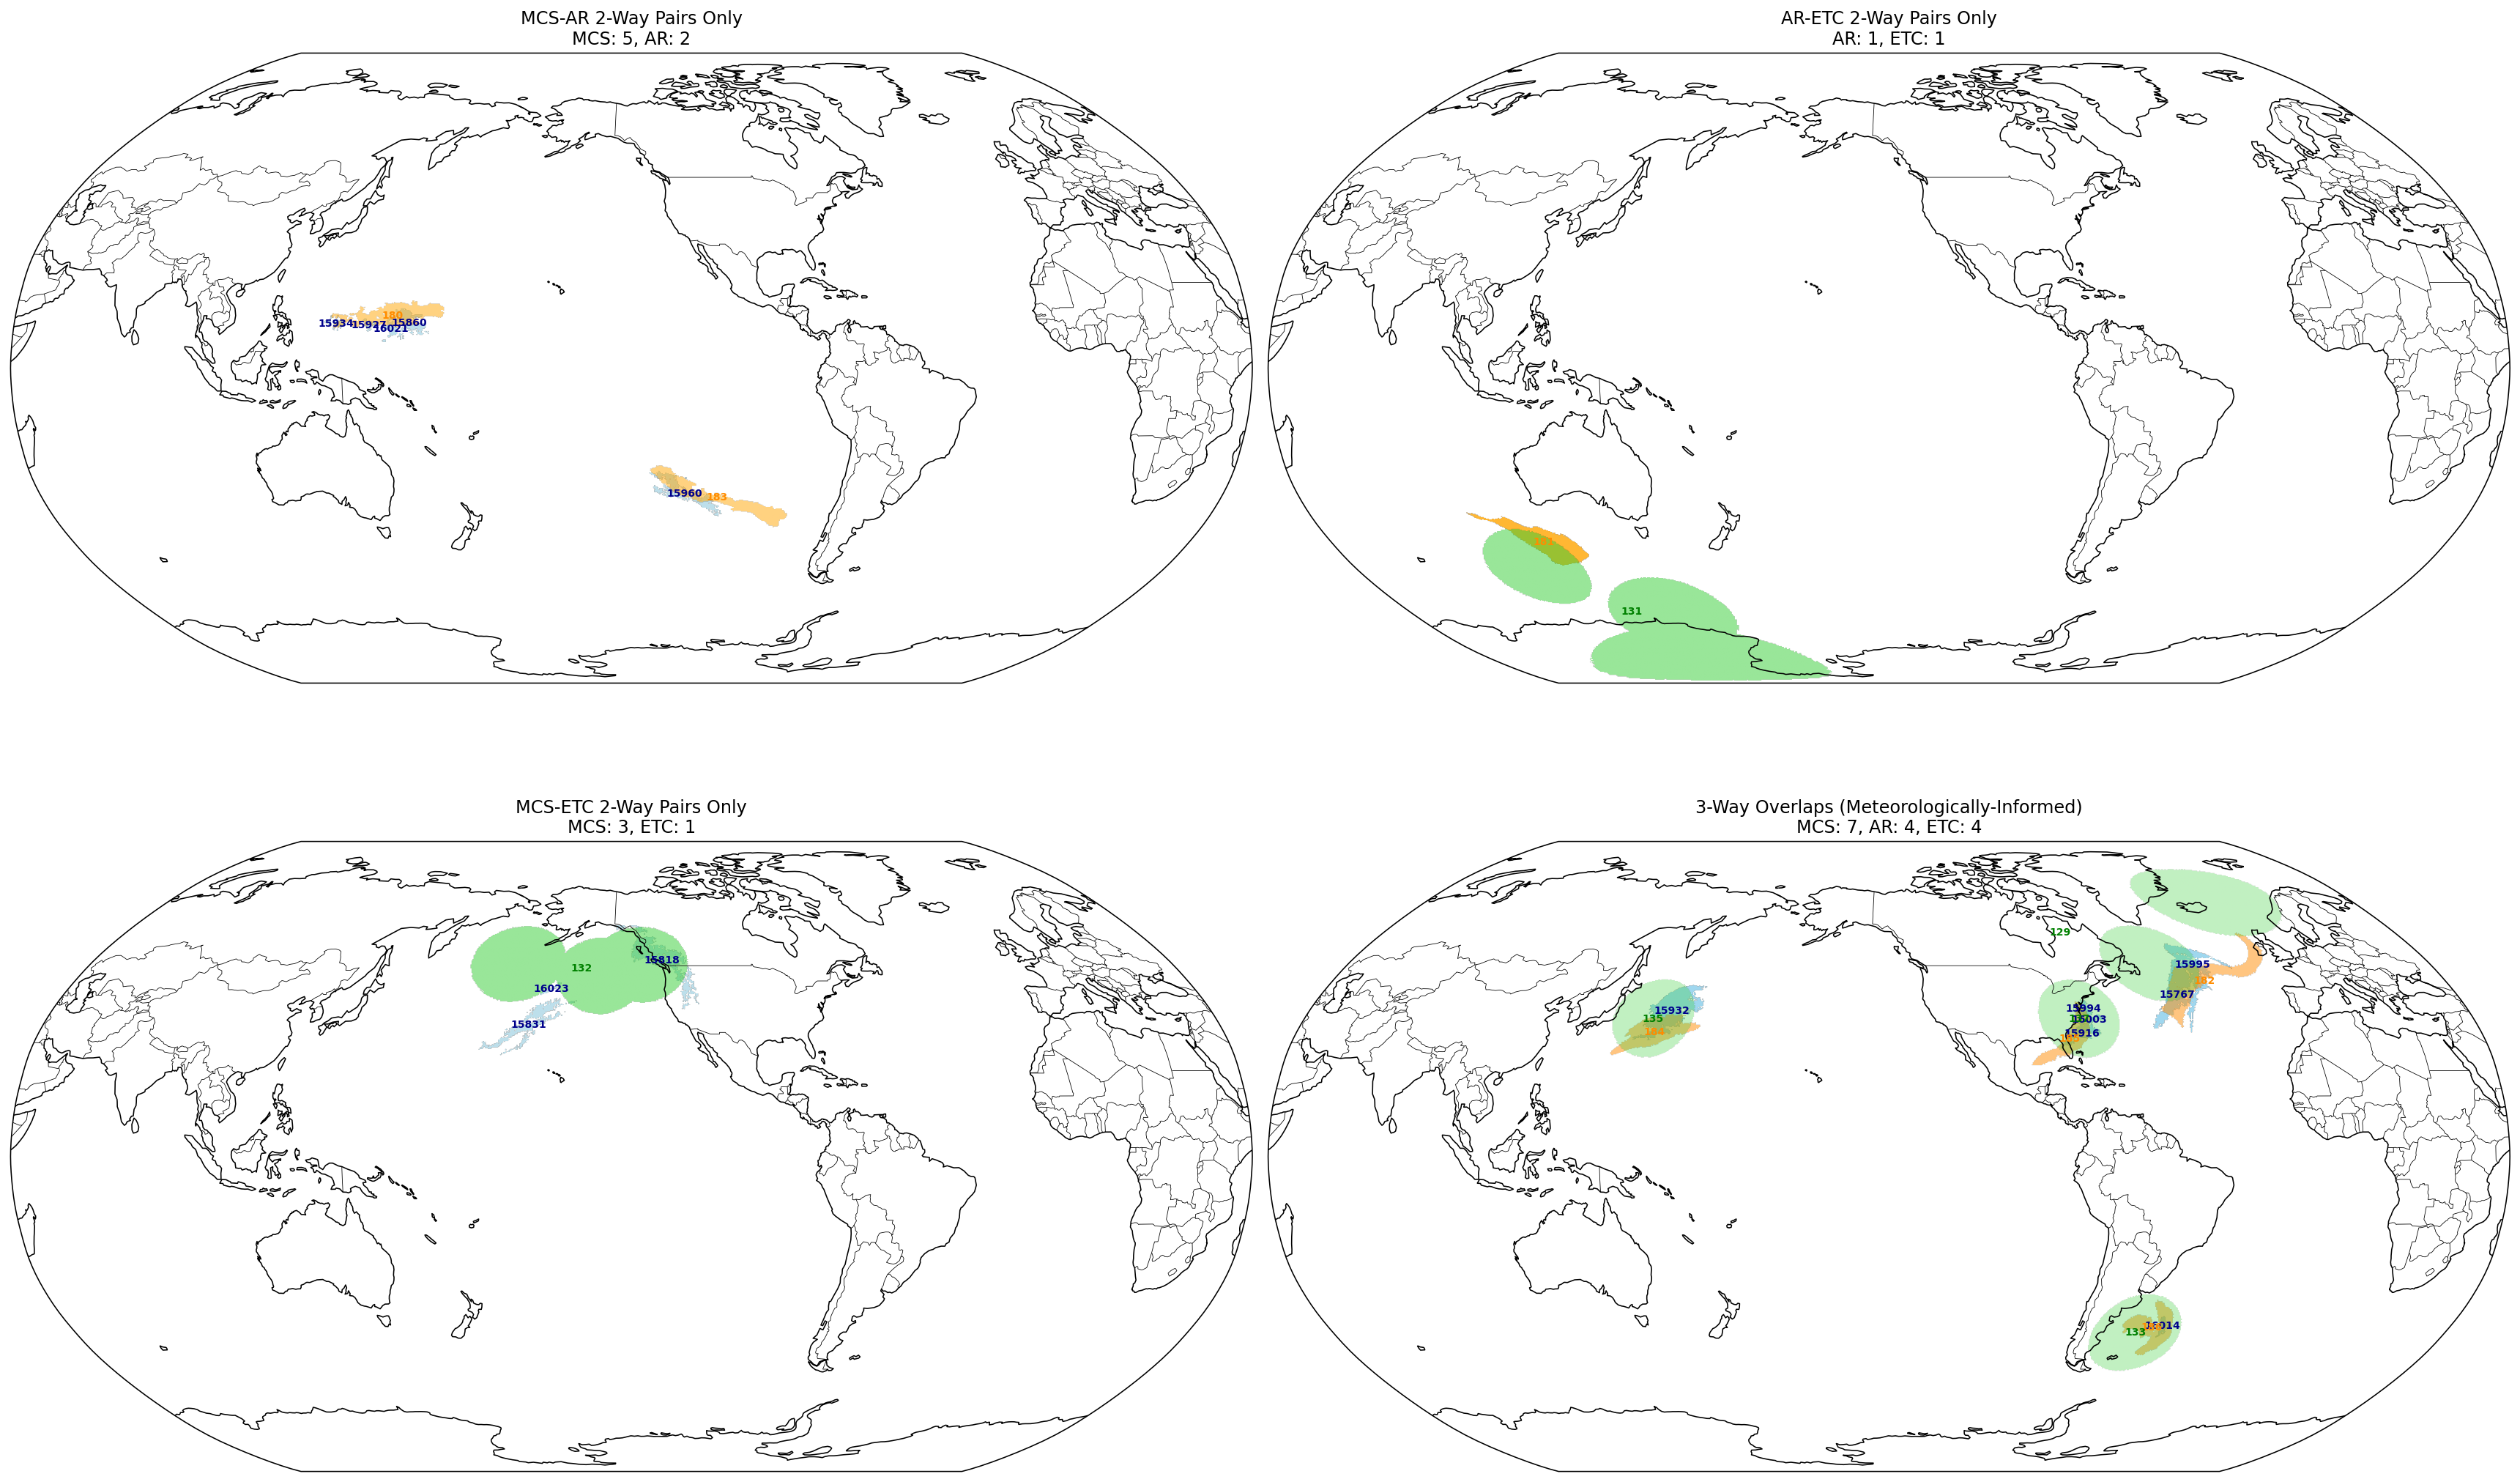


COMPREHENSIVE ANALYSIS SUMMARY:         
2-way MCS-AR pairs: 5
2-way AR-ETC pairs: 1
2-way MCS-ETC pairs: 3
3-way overlaps: 7 MCS, 4 AR, 4 ETC

✅ Meteorologically-informed feature interaction analysis complete! 🎉


In [20]:
# COMPREHENSIVE 4-PANEL VISUALIZATION WITH METEOROLOGICALLY-INFORMED ANALYSIS
print("Creating comprehensive 4-panel visualization...")

projection = ccrs.Robinson(central_longitude=-135)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(24, 16), 
                                             subplot_kw={"projection": projection})

# Add coastlines and features to all axes
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_global()
    ax.add_feature(cf.COASTLINE, linewidth=0.8)
    ax.add_feature(cf.BORDERS, linewidth=0.4)

fontsize_tracks = 7

# Panel 1: MCS-AR 2-way pairs only (pair-based filtering)
plt.sca(ax1)
if len(mcs_tracks_paired_2way_only) > 0:
    im_mcs_ar = egh.healpix_show(
        mcs_ar_overlap_mask_pairs.where(mcs_ar_overlap_mask_pairs > 0), 
        cmap=mpl.colors.ListedColormap('lightblue'), dpi=144, alpha=0.8, ax=ax1)
if len(ar_tracks_paired_2way_only) > 0:
    im_ar_mcs = egh.healpix_show(
        ar_mcs_overlap_mask_pairs.where(ar_mcs_overlap_mask_pairs > 0), 
        cmap=mpl.colors.ListedColormap('orange'), dpi=144, alpha=0.5, ax=ax1)

# Annotations for MCS-AR (CORRECTED: use corrected track lists)
for track_id in mcs_tracks_paired_corrected:
    track_pixels = _ds.mcs_mask == track_id
    if track_pixels.any():
        avg_lon = _ds.lon.where(track_pixels).mean().compute().item()
        avg_lat = _ds.lat.where(track_pixels).mean().compute().item()
        ax1.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                fontsize=fontsize_tracks, fontweight='bold', color='darkblue', ha='center', va='center')

for track_id in ar_tracks_paired_corrected:
    track_pixels = _ds.ar_mask == track_id
    if track_pixels.any():
        avg_lon = _ds.lon.where(track_pixels).mean().compute().item()
        avg_lat = _ds.lat.where(track_pixels).mean().compute().item()
        ax1.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                fontsize=fontsize_tracks, fontweight='bold', color='darkorange', ha='center', va='center')

ax1.set_title(f"MCS-AR 2-Way Pairs Only\nMCS: {len(mcs_tracks_paired_corrected)}, AR: {len(ar_tracks_paired_corrected)}")

# Panel 2: AR-ETC 2-way pairs only (pair-based filtering)
plt.sca(ax2)
if len(ar_tracks_paired_with_etc_2way_only) > 0:
    im_ar_etc = egh.healpix_show(
        ar_etc_overlap_mask_pairs.where(ar_etc_overlap_mask_pairs > 0), 
        cmap=mpl.colors.ListedColormap('orange'), dpi=144, alpha=0.8, ax=ax2)
if len(etc_tracks_paired_with_ar_2way_only) > 0:
    im_etc_ar = egh.healpix_show(
        etc_ar_overlap_mask_pairs.where(etc_ar_overlap_mask_pairs > 0), 
        cmap=mpl.colors.ListedColormap('limegreen'), dpi=144, alpha=0.5, ax=ax2)

# Annotations for AR-ETC (CORRECTED: use corrected track lists)
for track_id in ar_tracks_paired_with_etc_corrected:
    track_pixels = _ds.ar_mask == track_id
    if track_pixels.any():
        avg_lon = _ds.lon.where(track_pixels).mean().compute().item()
        avg_lat = _ds.lat.where(track_pixels).mean().compute().item()
        ax2.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                fontsize=fontsize_tracks, fontweight='bold', color='darkorange', ha='center', va='center')

for track_id in etc_tracks_paired_with_ar_corrected:
    track_pixels = _ds.etc_mask == track_id
    if track_pixels.any():
        avg_lon = _ds.lon.where(track_pixels).mean().compute().item()
        avg_lat = _ds.lat.where(track_pixels).mean().compute().item()
        ax2.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                fontsize=fontsize_tracks, fontweight='bold', color='green', ha='center', va='center')

ax2.set_title(f"AR-ETC 2-Way Pairs Only\nAR: {len(ar_tracks_paired_with_etc_corrected)}, ETC: {len(etc_tracks_paired_with_ar_corrected)}")

# Panel 3: MCS-ETC 2-way pairs only (pair-based filtering)
plt.sca(ax3)
if len(mcs_tracks_paired_with_etc_2way_only) > 0:
    im_mcs_etc = egh.healpix_show(
        mcs_etc_overlap_mask_pairs.where(mcs_etc_overlap_mask_pairs > 0), 
        cmap=mpl.colors.ListedColormap('lightblue'), dpi=144, alpha=0.8, ax=ax3)
if len(etc_tracks_paired_with_mcs_2way_only) > 0:
    im_etc_mcs = egh.healpix_show(
        etc_mcs_overlap_mask_pairs.where(etc_mcs_overlap_mask_pairs > 0), 
        cmap=mpl.colors.ListedColormap('limegreen'), dpi=144, alpha=0.5, ax=ax3)

# Annotations for MCS-ETC (CORRECTED: use corrected track lists)
for track_id in mcs_tracks_paired_with_etc_corrected:
    track_pixels = _ds.mcs_mask == track_id
    if track_pixels.any():
        avg_lon = _ds.lon.where(track_pixels).mean().compute().item()
        avg_lat = _ds.lat.where(track_pixels).mean().compute().item()
        ax3.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                fontsize=fontsize_tracks, fontweight='bold', color='darkblue', ha='center', va='center')

for track_id in etc_tracks_paired_with_mcs_corrected:
    track_pixels = _ds.etc_mask == track_id
    if track_pixels.any():
        avg_lon = _ds.lon.where(track_pixels).mean().compute().item()
        avg_lat = _ds.lat.where(track_pixels).mean().compute().item()
        ax3.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                fontsize=fontsize_tracks, fontweight='bold', color='green', ha='center', va='center')

ax3.set_title(f"MCS-ETC 2-Way Pairs Only\nMCS: {len(mcs_tracks_paired_with_etc_corrected)}, ETC: {len(etc_tracks_paired_with_mcs_corrected)}")

# Panel 4: 3-way overlaps (meteorologically-informed with ETC threshold = 0%)
plt.sca(ax4)
im_mcs_3way = egh.healpix_show(
    mcs_ar_etc_overlap_mask.where(mcs_ar_etc_overlap_mask > 0), 
    cmap=mpl.colors.ListedColormap('skyblue'), dpi=144, alpha=0.8, ax=ax4)
im_ar_3way = egh.healpix_show(
    ar_mcs_etc_overlap_mask.where(ar_mcs_etc_overlap_mask > 0), 
    cmap=mpl.colors.ListedColormap('darkorange'), dpi=144, alpha=0.5, ax=ax4)
im_etc_3way = egh.healpix_show(
    etc_mcs_ar_overlap_mask.where(etc_mcs_ar_overlap_mask > 0),
    cmap=mpl.colors.ListedColormap('limegreen'), dpi=144, alpha=0.3, ax=ax4)

# Annotations for 3-way overlaps
for track_id in mcs_tracks_with_ar_etc_overlap:
    track_pixels = _ds.mcs_mask == track_id
    if track_pixels.any():
        avg_lon = _ds.lon.where(track_pixels).mean().compute().item()
        avg_lat = _ds.lat.where(track_pixels).mean().compute().item()
        ax4.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                fontsize=fontsize_tracks, fontweight='bold', color='darkblue', ha='center', va='center')

for track_id in ar_tracks_with_mcs_etc_overlap:
    track_pixels = _ds.ar_mask == track_id
    if track_pixels.any():
        avg_lon = _ds.lon.where(track_pixels).mean().compute().item()
        avg_lat = _ds.lat.where(track_pixels).mean().compute().item()
        ax4.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                fontsize=fontsize_tracks, fontweight='bold', color='darkorange', ha='center', va='center')

for track_id in etc_tracks_with_mcs_ar_overlap:
    track_pixels = _ds.etc_mask == track_id
    if track_pixels.any():
        avg_lon = _ds.lon.where(track_pixels).mean().compute().item()
        avg_lat = _ds.lat.where(track_pixels).mean().compute().item()
        ax4.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                fontsize=fontsize_tracks, fontweight='bold', color='green', ha='center', va='center')

ax4.set_title(f"3-Way Overlaps (Meteorologically-Informed)\nMCS: {len(mcs_tracks_with_ar_etc_overlap)}, AR: {len(ar_tracks_with_mcs_etc_overlap)}, ETC: {len(etc_tracks_with_mcs_ar_overlap)}")

plt.tight_layout()
plt.show()

print(f"\n{'COMPREHENSIVE ANALYSIS SUMMARY:':<40}")
print("="*50)
print(f"2-way MCS-AR pairs: {len(mcs_ar_pairs_2way_only)}")
print(f"2-way AR-ETC pairs: {len(ar_etc_pairs_2way_only)}")
print(f"2-way MCS-ETC pairs: {len(mcs_etc_pairs_2way_only)}")
print(f"3-way overlaps: {len(mcs_tracks_with_ar_etc_overlap)} MCS, {len(ar_tracks_with_mcs_etc_overlap)} AR, {len(etc_tracks_with_mcs_ar_overlap)} ETC")

print(f"\n✅ Meteorologically-informed feature interaction analysis complete! 🎉")

In [ ]:
figdir

## Analysis Summary

This notebook successfully implements a meteorologically-informed framework for analyzing multi-feature atmospheric interactions:

### **Key Achievements:**

1. **Meteorological Scale Hierarchy**: 
   - ETC threshold = 0% for 3-way overlaps recognizes large-scale environmental context
   - Threshold progression: MCS (20%) > AR (10%) > ETC (5%/0%) respects feature sizes

2. **Pair-Based Filtering**:
   - Eliminates orphaned track visualization issues
   - Ensures spatial consistency between overlapping features
   - Maintains visual integrity across all panels

3. **Comprehensive Coverage**:
   - All possible 2-way combinations (MCS-AR, AR-ETC, MCS-ETC)
   - 3-way interactions with proper environmental context
   - Mutually exclusive categorization preventing double-counting

4. **Scientific Robustness**:
   - Vectorized algorithms for computational efficiency
   - Configurable thresholds for different research applications
   - Detailed validation and verification capabilities

The framework provides a foundation for studying complex atmospheric interactions while maintaining both computational efficiency and meteorological realism.